In [4]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
# STEP 1 - LOAD ALL FILES AND BUILD METADATA TABLE
BASE = Path(r'C:\Users\mariaplumber\Downloads')

DATA_DIRS = {
    'HSV1':          BASE / 'HHV11',
    'HCMV':          BASE / 'HCMV5',
    'Aspergillus':   BASE / 'Asper',
    'Candida':       BASE / 'Cand',
    'Mycobacterium': BASE / 'Myc',
    'Pseudomonas':   BASE / 'Pseu',
}

ACC_RE = re.compile(r'^[SED]RR\d+$')

records, skipped = [], []

for group, d in DATA_DIRS.items():
    if not d.exists():
        print(f"[WARN] directory not found: {d}")
        continue

    files = sorted(d.glob('*.xlsx'))
    n_ok = 0
    for f in files:
        if f.name.startswith('~$'):          # Excel lock files
            continue
        parts = f.stem.split('_')
        if len(parts) < 5:
            skipped.append((group, f.name, 'too few fields'))
            continue
        pathogen, condition, srr_id, prjna_id = parts[0], parts[1], parts[2], parts[3]
        cell_type = '_'.join(parts[4:])
        if not ACC_RE.match(srr_id):
            skipped.append((group, f.name, f'unexpected accession field: {srr_id}'))
            continue
        records.append({
            'filename':   f,
            'group':      group,          # directory the file came from
            'pathogen':   pathogen,
            'condition':  condition,
            'srr_id':     srr_id,
            'study':      prjna_id,
            'cell_type':  cell_type,
        })
        n_ok += 1
    print(f"{group:14s} {d.name:8s}  {n_ok:4d} files parsed  ({len(files)} found)")

meta_all = pd.DataFrame(records)

print(f"\nTotal files parsed: {len(meta_all)}")
if skipped:
    print(f"Skipped {len(skipped)} file(s):")
    for g, name, why in skipped:
        print(f"  [{g}] {name} -> {why}")

# sanity checks
print("\nPathogen tokens per directory:")
print(meta_all.groupby('group')['pathogen'].unique())

dupes = meta_all['srr_id'][meta_all['srr_id'].duplicated()].unique()
if len(dupes):
    print(f"\n[WARN] {len(dupes)} accession(s) appear in more than one file: {list(dupes)[:10]}")

summary = (meta_all
           .groupby(['group', 'pathogen', 'condition', 'study', 'cell_type'])
           .size().reset_index(name='n_samples'))
print(f"\n{summary.to_string(index=False)}")

HSV1           HHV11       56 files parsed  (56 found)
HCMV           HCMV5       52 files parsed  (52 found)
Aspergillus    Asper       63 files parsed  (63 found)
Candida        Cand        52 files parsed  (52 found)
Mycobacterium  Myc         51 files parsed  (51 found)
Pseudomonas    Pseu        56 files parsed  (56 found)

Total files parsed: 330

Pathogen tokens per directory:
group
Aspergillus      [Aspergillus]
Candida              [Candida]
HCMV                    [HCMV]
HSV1                    [HSV1]
Mycobacterium         [Myctub]
Pseudomonas          [Pseuaer]
Name: pathogen, dtype: object

        group    pathogen condition        study                   cell_type  n_samples
  Aspergillus Aspergillus  infected    PRJEB1587                   Dendritic          6
  Aspergillus Aspergillus  infected PRJNA1080579                 Neutrophils          4
  Aspergillus Aspergillus  infected  PRJNA301940 Monocyte-derived-Macrophage         12
  Aspergillus Aspergillus  infected  P

In [ ]:
# ============================================================
# STEP 2 - BUILD TPM AND COUNTS MATRICES (per pathogen)
# ============================================================

tpm_by_pathogen    = {}
counts_by_pathogen = {}
meta_by_pathogen   = {}

REQUIRED_COLS = {'target_id', 'tpm', 'est_counts'}

for group in DATA_DIRS:
    sub = meta_all[meta_all['group'] == group]
    if sub.empty:
        print(f"[WARN] no files for {group}, skipping")
        continue

    print(f"\n=== {group} ({len(sub)} files) ===")
    tpm_dict, counts_dict, index_sets = {}, {}, {}

    for i, (_, row) in enumerate(sub.iterrows(), 1):
        df = pd.read_excel(row['filename'])
        missing = REQUIRED_COLS - set(df.columns)
        if missing:
            print(f"  [SKIP] {row['filename'].name} missing columns: {sorted(missing)}")
            continue

        df['target_id'] = df['target_id'].astype(str).str.split('.').str[0]

        # collapse duplicate IDs created by version stripping
        agg = df.groupby('target_id')[['tpm', 'est_counts']].sum()

        tpm_dict[row['srr_id']]    = agg['tpm']
        counts_dict[row['srr_id']] = agg['est_counts']
        index_sets[row['srr_id']]  = set(agg.index)

        if i % 10 == 0 or i == len(sub):
            print(f"  loaded {i}/{len(sub)}")

    tpm    = pd.DataFrame(tpm_dict)
    counts = pd.DataFrame(counts_dict)

    # flag samples quantified against a different transcriptome index
    ref = max(index_sets.values(), key=len)
    odd = {s: len(ref - ids) for s, ids in index_sets.items() if ids != ref}
    if odd:
        print(f"  [WARN] {len(odd)} sample(s) have a different transcript set "
              f"(max missing: {max(odd.values())} IDs) -> NaNs introduced")

    meta = sub.set_index('srr_id').loc[tpm.columns].copy()

    tpm_by_pathogen[group]    = tpm
    counts_by_pathogen[group] = counts
    meta_by_pathogen[group]   = meta

    print(f"  TPM: {tpm.shape}   counts: {counts.shape}   NaNs in TPM: {int(tpm.isna().sum().sum())}")
    print(f"  conditions: {dict(meta['condition'].value_counts())}")
    print(f"  studies: {meta['study'].nunique()}   cell types: {meta['cell_type'].nunique()}")

# ---- overall summary ----
print("\n SUMMARY ")
overview = pd.DataFrame({
    'n_samples':    {g: m.shape[0] for g, m in meta_by_pathogen.items()},
    'n_transcripts':{g: t.shape[0] for g, t in tpm_by_pathogen.items()},
    'n_studies':    {g: m['study'].nunique() for g, m in meta_by_pathogen.items()},
    'n_cell_types': {g: m['cell_type'].nunique() for g, m in meta_by_pathogen.items()},
    'n_mock':       {g: int((m['condition'].str.lower() == 'mock').sum())
                     for g, m in meta_by_pathogen.items()},
})
print(overview.to_string())


=== HSV1 (56 files) ===
  loaded 10/56
  loaded 20/56
  loaded 30/56
  loaded 40/56
  loaded 50/56
  loaded 56/56
  TPM: (207175, 56)   counts: (207175, 56)   NaNs in TPM: 0
  conditions: {'infected': np.int64(34), 'mock': np.int64(22)}
  studies: 6   cell types: 5

=== HCMV (52 files) ===
  loaded 10/52
  loaded 20/52
  loaded 30/52
  loaded 40/52
  loaded 50/52
  loaded 52/52
  TPM: (207175, 52)   counts: (207175, 52)   NaNs in TPM: 0
  conditions: {'infected': np.int64(26), 'mock': np.int64(26)}
  studies: 7   cell types: 4

=== Aspergillus (63 files) ===
  loaded 10/63
  loaded 20/63
  loaded 30/63
  loaded 40/63
  loaded 50/63
  loaded 60/63
  loaded 63/63
  TPM: (207175, 63)   counts: (207175, 63)   NaNs in TPM: 0
  conditions: {'infected': np.int64(35), 'mock': np.int64(28)}
  studies: 6   cell types: 3

=== Candida (52 files) ===
  loaded 10/52
  loaded 20/52
  loaded 30/52
  loaded 40/52
  loaded 50/52
  loaded 52/52
  TPM: (207175, 52)   counts: (207175, 52)   NaNs in TPM: 0

In [51]:
# ============================================================
# STEP 2.5 - TRANSCRIPT TO GENE CONVERSION (per pathogen)
# ============================================================

TX2GENE = r"D:\HHVBiomaker\tx2gene.tsv"

tx2gene = pd.read_csv(TX2GENE, sep="\t")
tx2gene["target_id"] = tx2gene["target_id"].astype(str).str.split(".").str[0]
tx2gene = tx2gene[["target_id", "gene_name"]].dropna().drop_duplicates("target_id")
print(f"tx2gene: {len(tx2gene)} transcripts -> {tx2gene['gene_name'].nunique()} genes")


def transcripts_to_genes(matrix, tx2gene_df, method="sum"):
    merged = (matrix
              .reset_index()
              .rename(columns={matrix.index.name or "index": "target_id"})
              .merge(tx2gene_df, on="target_id", how="inner")
              .drop(columns=["target_id"]))
    grouped = merged.groupby("gene_name")
    return grouped.sum() if method == "sum" else grouped.mean()


counts_gene_by_pathogen = {}
tpm_gene_by_pathogen    = {}

for group in tpm_by_pathogen:
    tpm_tx    = tpm_by_pathogen[group]
    counts_tx = counts_by_pathogen[group]

    overlap = set(tpm_tx.index) & set(tx2gene["target_id"])
    rate = len(overlap) / len(tpm_tx) * 100
    flag = "  <-- CHECK" if rate < 90 else ""
    print(f"\n=== {group} ===")
    print(f"  mapping rate: {rate:.1f}%  ({len(overlap)}/{len(tpm_tx)} transcripts){flag}")

    counts_gene = transcripts_to_genes(counts_tx, tx2gene, method="sum")
    tpm_gene    = transcripts_to_genes(tpm_tx,    tx2gene, method="sum")

    counts_gene_by_pathogen[group] = counts_gene
    tpm_gene_by_pathogen[group]    = tpm_gene

    colsums = tpm_gene.sum(axis=0)
    print(f"  counts: {counts_tx.shape} -> {counts_gene.shape}")
    print(f"  TPM:    {tpm_tx.shape} -> {tpm_gene.shape}")
    print(f"  TPM column sums: min {colsums.min():,.0f}  max {colsums.max():,.0f}")

# ---- gene-space consistency across pathogens ----
gene_sets = {g: set(m.index) for g, m in tpm_gene_by_pathogen.items()}
common = set.intersection(*gene_sets.values())
union  = set.union(*gene_sets.values())
print("\n================ GENE SPACE ================")
for g, s in gene_sets.items():
    print(f"  {g:14s} {len(s):6d} genes   ({len(union - s)} absent vs union)")
print(f"  common to all six: {len(common)}   union: {len(union)}")

tx2gene: 216741 transcripts -> 56643 genes

=== HSV1 ===
  mapping rate: 82.2%  (170349/207175 transcripts)  <-- CHECK
  counts: (207175, 56) -> (35300, 56)
  TPM:    (207175, 56) -> (35300, 56)
  TPM column sums: min 865,519  max 988,221

=== HCMV ===
  mapping rate: 82.2%  (170349/207175 transcripts)  <-- CHECK
  counts: (207175, 52) -> (35300, 52)
  TPM:    (207175, 52) -> (35300, 52)
  TPM column sums: min 837,425  max 953,532

=== Aspergillus ===
  mapping rate: 82.2%  (170349/207175 transcripts)  <-- CHECK
  counts: (207175, 63) -> (35300, 63)
  TPM:    (207175, 63) -> (35300, 63)
  TPM column sums: min 864,963  max 925,407

=== Candida ===
  mapping rate: 82.2%  (170349/207175 transcripts)  <-- CHECK
  counts: (207175, 52) -> (35300, 52)
  TPM:    (207175, 52) -> (35300, 52)
  TPM column sums: min 885,296  max 947,432

=== Mycobacterium ===
  mapping rate: 82.2%  (170349/207175 transcripts)  <-- CHECK
  counts: (207175, 51) -> (35300, 51)
  TPM:    (207175, 51) -> (35300, 51)
  

In [52]:
# ============================================================
# STEP 3 - GENTLE PRE-FILTER (per pathogen)
# CPM > 0.5 in at least 10% of samples
# ============================================================

counts_filt_by_pathogen = {}
tpm_filt_by_pathogen    = {}

for group in counts_gene_by_pathogen:
    counts_gene = counts_gene_by_pathogen[group]
    tpm_gene    = tpm_gene_by_pathogen[group]

    total_counts    = counts_gene.sum(axis=0)
    cpm_matrix_gene = counts_gene.divide(total_counts, axis=1) * 1e6
    min_samples     = int(0.10 * counts_gene.shape[1])
    keep            = (cpm_matrix_gene > 0.5).sum(axis=1) >= min_samples

    counts_filt_by_pathogen[group] = counts_gene[keep]
    tpm_filt_by_pathogen[group]    = tpm_gene[keep]

    print(f"=== {group} ===")
    print(f"Before filter: {counts_gene.shape[0]} genes")
    print(f"After filter:  {counts_filt_by_pathogen[group].shape[0]} genes")

=== HSV1 ===
Before filter: 35300 genes
After filter:  21447 genes
=== HCMV ===
Before filter: 35300 genes
After filter:  18323 genes
=== Aspergillus ===
Before filter: 35300 genes
After filter:  16574 genes
=== Candida ===
Before filter: 35300 genes
After filter:  18506 genes
=== Mycobacterium ===
Before filter: 35300 genes
After filter:  17941 genes
=== Pseudomonas ===
Before filter: 35300 genes
After filter:  20702 genes


Pooled matrix: 35300 genes x 330 samples
pathogen_clean
Aspergillus      63
HSV1             56
Pseudomonas      56
HCMV             52
Candida          52
Mycobacterium    51
Name: count, dtype: int64


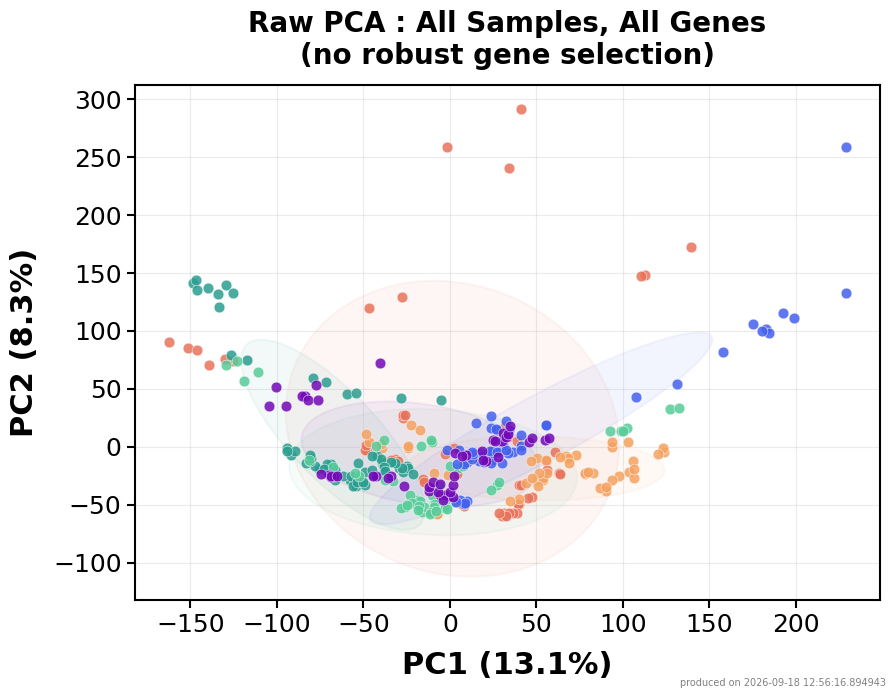

Raw PCA saved! 35300 genes, 330 samples used


In [54]:
# ============================================================
# RAW PCA (ALL SAMPLES, ALL GENES, NO FILTERING)
# ============================================================
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
from datetime import datetime

OUT = r'C:\Users\mariaplumber\Downloads'


def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)


# ---- pool the per-pathogen gene matrices (gene space is identical across all six) ----
tpm_gene_pooled = pd.concat(
    [tpm_gene_by_pathogen[g] for g in tpm_gene_by_pathogen], axis=1
)
meta_pooled = pd.concat(
    [meta_by_pathogen[g] for g in meta_by_pathogen]
).loc[tpm_gene_pooled.columns]

print(f"Pooled matrix: {tpm_gene_pooled.shape[0]} genes x "
      f"{tpm_gene_pooled.shape[1]} samples")

# use ALL genes, ALL samples — no robust gene filtering
X_raw = np.log2(tpm_gene_pooled.T + 1)
X_raw_scaled = StandardScaler().fit_transform(X_raw)

pca_raw   = PCA(n_components=10)
X_pca_raw = pca_raw.fit_transform(X_raw_scaled)
var_raw   = pca_raw.explained_variance_ratio_ * 100

pca_raw_df = pd.DataFrame(
    X_pca_raw[:, :3],
    index=tpm_gene_pooled.columns,
    columns=['PC1', 'PC2', 'PC3']
)
pca_raw_df = pca_raw_df.join(
    meta_pooled[['pathogen', 'condition', 'study', 'cell_type']]
)
pca_raw_df['pathogen_clean'] = pca_raw_df['pathogen'].replace(
    {'Myctub': 'Mycobacterium', 'Pseuaer': 'Pseudomonas'}
)

pathogen_colors = {
    'HSV1':          '#E8735A',
    'HCMV':          '#F4A261',
    'Aspergillus':   '#2A9D8F',
    'Candida':       '#57CC99',
    'Pseudomonas':   '#4361EE',
    'Mycobacterium': '#7209B7',
    'Mock':          '#999999',
}

# ---- plot ----
fig, ax = plt.subplots(figsize=(9, 7))

plot_order = ['Mock'] + [p for p in pathogen_colors if p != 'Mock']
for pathogen in plot_order:
    grp = pca_raw_df[pca_raw_df['pathogen_clean'] == pathogen]
    if len(grp) == 0:
        continue
    ax.scatter(
        grp['PC1'], grp['PC2'],
        c=pathogen_colors[pathogen],
        s=60 if pathogen != 'Mock' else 40,
        alpha=0.85 if pathogen != 'Mock' else 0.5,
        label=f"{pathogen} (n={len(grp)})",
        edgecolors='white', linewidths=0.4,
        zorder=3 if pathogen != 'Mock' else 1
    )
    confidence_ellipse(
        grp['PC1'].values, grp['PC2'].values, ax,
        n_std=1.5, edgecolor=pathogen_colors[pathogen],
        linewidth=1.5, facecolor=pathogen_colors[pathogen], alpha=0.06
    )

ax.set_xlabel(f'PC1 ({var_raw[0]:.1f}%)', fontsize=22, fontweight='bold', labelpad=10)
ax.set_ylabel(f'PC2 ({var_raw[1]:.1f}%)', fontsize=22, fontweight='bold', labelpad=10)
ax.set_title('Raw PCA : All Samples, All Genes\n(no robust gene selection)',
             fontsize=20, fontweight='bold', pad=15)
ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=6)
print(pca_raw_df['pathogen_clean'].value_counts())

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(True, alpha=0.25)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')
fig.text(0.99, 0.01, f'produced on {timestamp}',
         ha='right', va='bottom', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(f"{OUT}/PCA_raw_all_samples_all_genes.png",
            dpi=300, bbox_inches='tight')
plt.show()
print(f"Raw PCA saved! {tpm_gene_pooled.shape[0]} genes, "
      f"{tpm_gene_pooled.shape[1]} samples used")

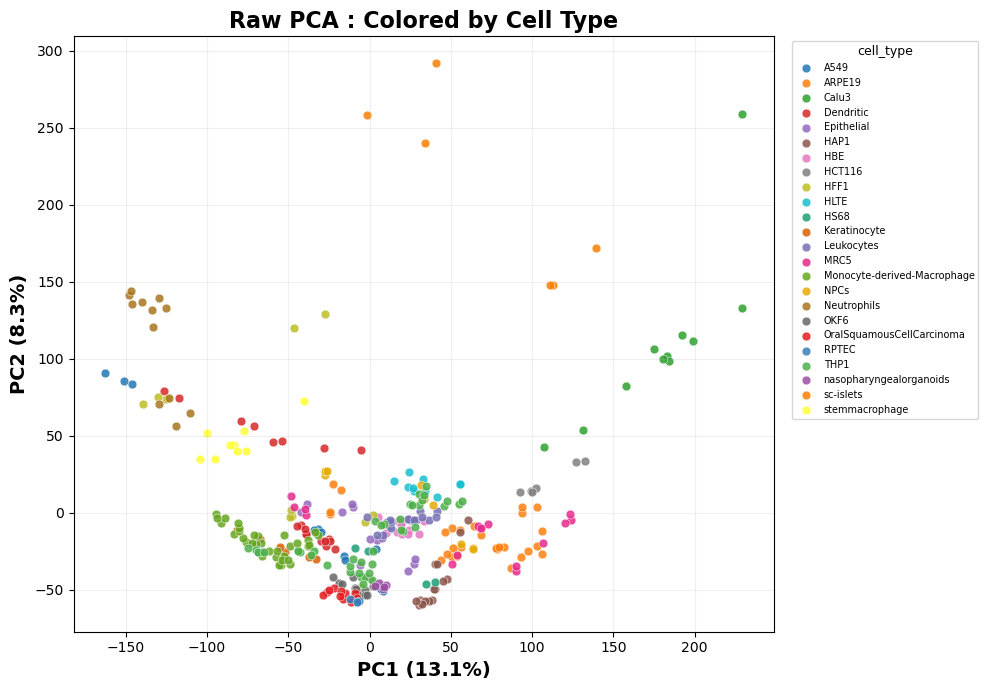

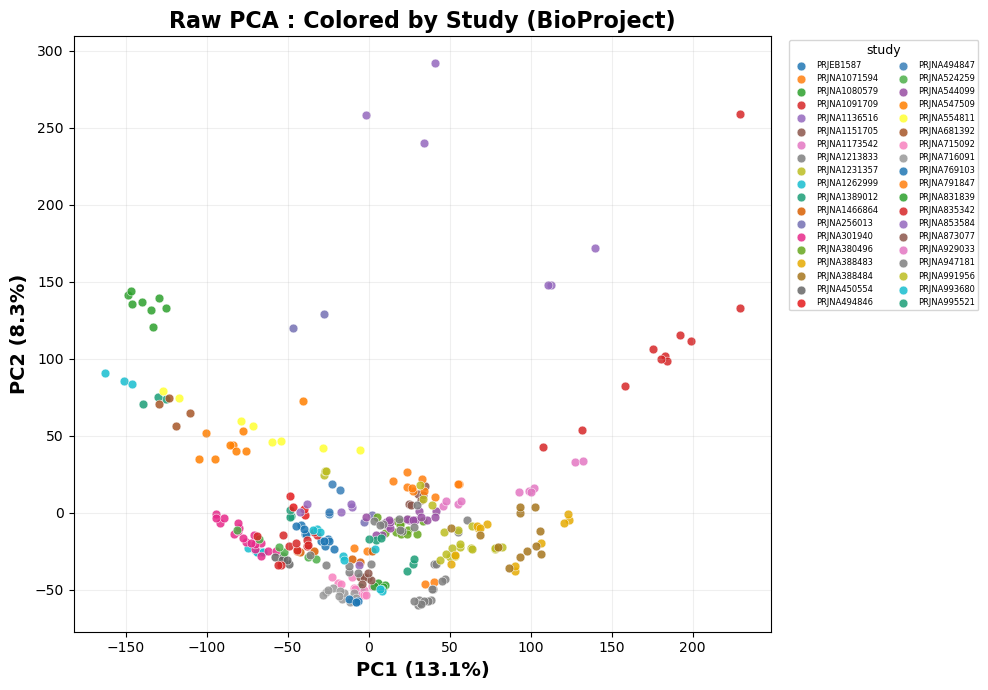

In [55]:
from matplotlib import colormaps

def categorical_palette(n):
    """Distinct discrete DARK colors, no interpolation."""
    base = (list(colormaps['tab10'].colors)
            + list(colormaps['Dark2'].colors)
            + list(colormaps['Set1'].colors))
    pal, seen = [], set()
    for c in base:
        if c not in seen:
            seen.add(c)
            pal.append(c)
    return [pal[i % len(pal)] for i in range(n)]

def plot_pca_by(col, title, fname, ncol=1, fontsize=7):
    cats = sorted(pca_raw_df[col].astype(str).unique())   # sorted = stable colors across runs
    pal = categorical_palette(len(cats))
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, c in enumerate(cats):
        grp = pca_raw_df[pca_raw_df[col].astype(str) == c]
        ax.scatter(grp['PC1'], grp['PC2'], s=40, alpha=0.85,
                   color=pal[i], marker='o',
                   label=c, edgecolors='white', linewidths=0.4)
    ax.set_xlabel(f'PC1 ({var_raw[0]:.1f}%)', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'PC2 ({var_raw[1]:.1f}%)', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(fontsize=fontsize, title=col, title_fontsize=9,
              bbox_to_anchor=(1.02, 1), loc='upper left', ncol=ncol)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"{OUT}/{fname}", dpi=300, bbox_inches='tight')
    plt.show()

plot_pca_by('cell_type', 'Raw PCA : Colored by Cell Type', 'raw_PCA_by_celltype.png')
plot_pca_by('study', 'Raw PCA : Colored by Study (BioProject)', 'raw_PCA_by_study.png', ncol=2, fontsize=6)

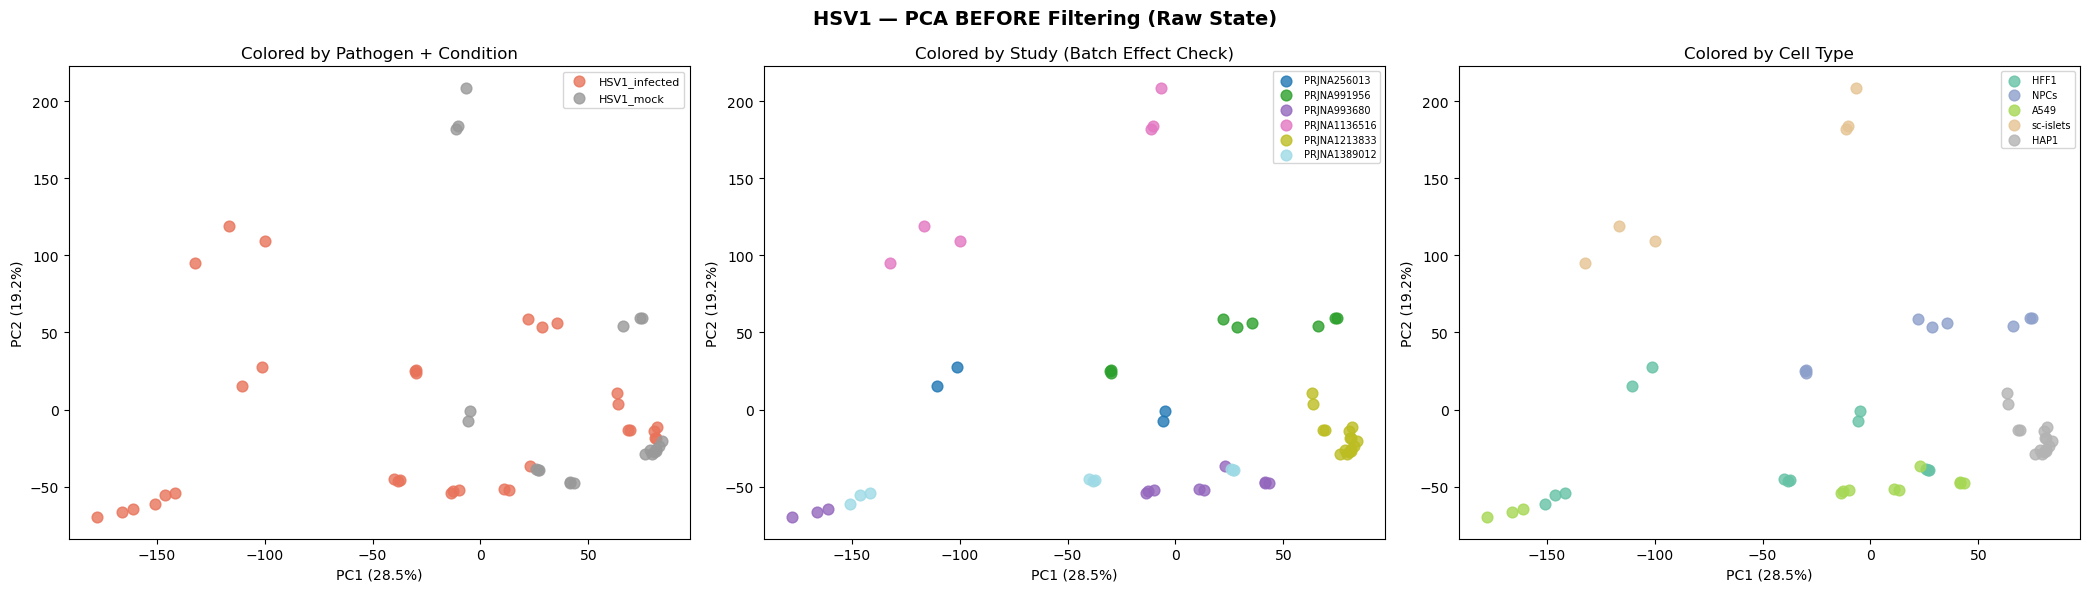

HSV1: PC1 28.5%, PC2 19.2% | 56 samples x 21447 genes -> PCA_before_filtering_HSV1.png


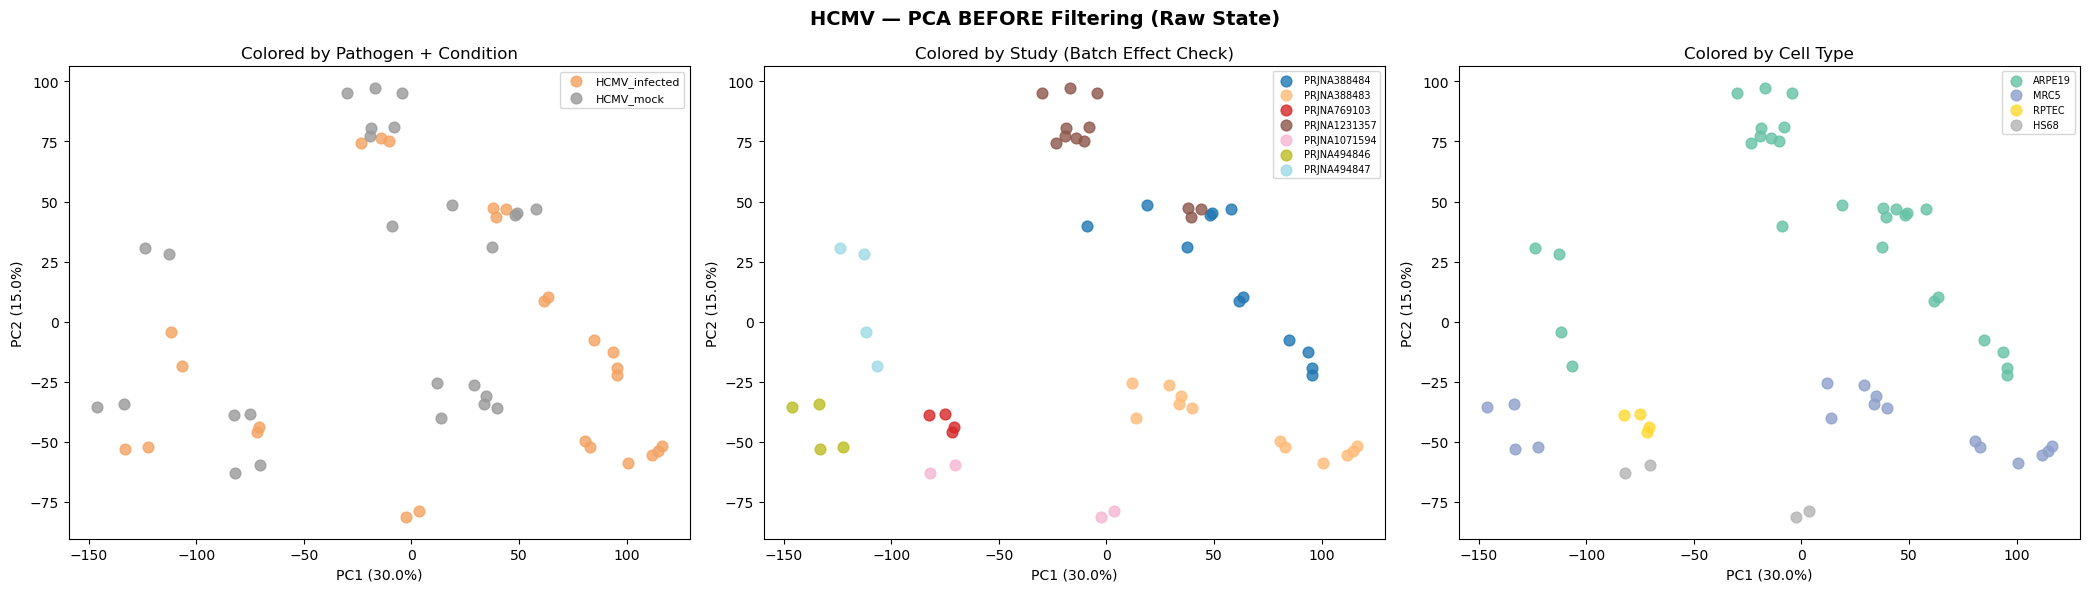

HCMV: PC1 30.0%, PC2 15.0% | 52 samples x 18323 genes -> PCA_before_filtering_HCMV.png


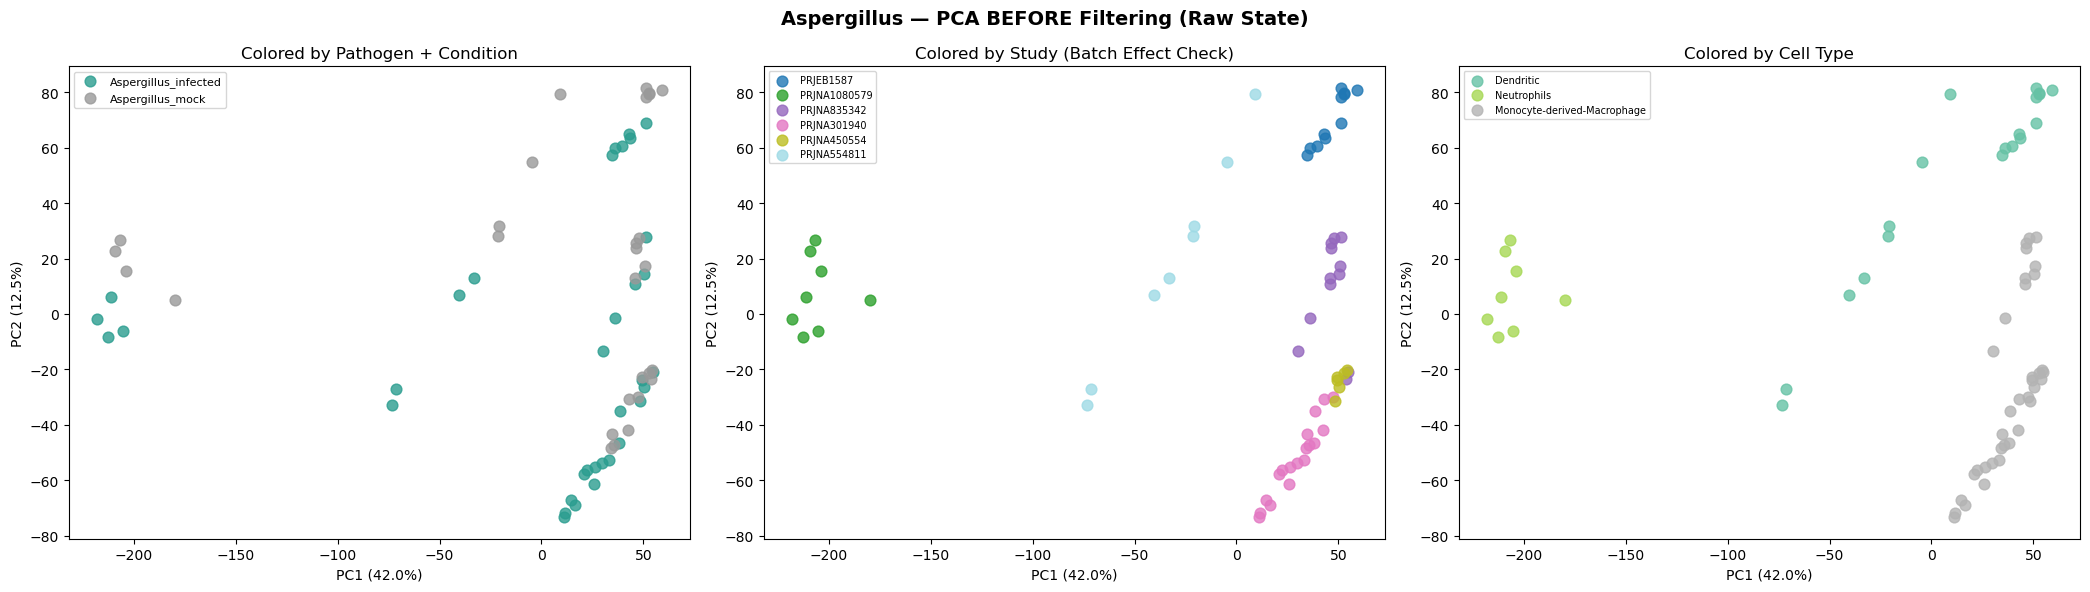

Aspergillus: PC1 42.0%, PC2 12.5% | 63 samples x 16574 genes -> PCA_before_filtering_Aspergillus.png


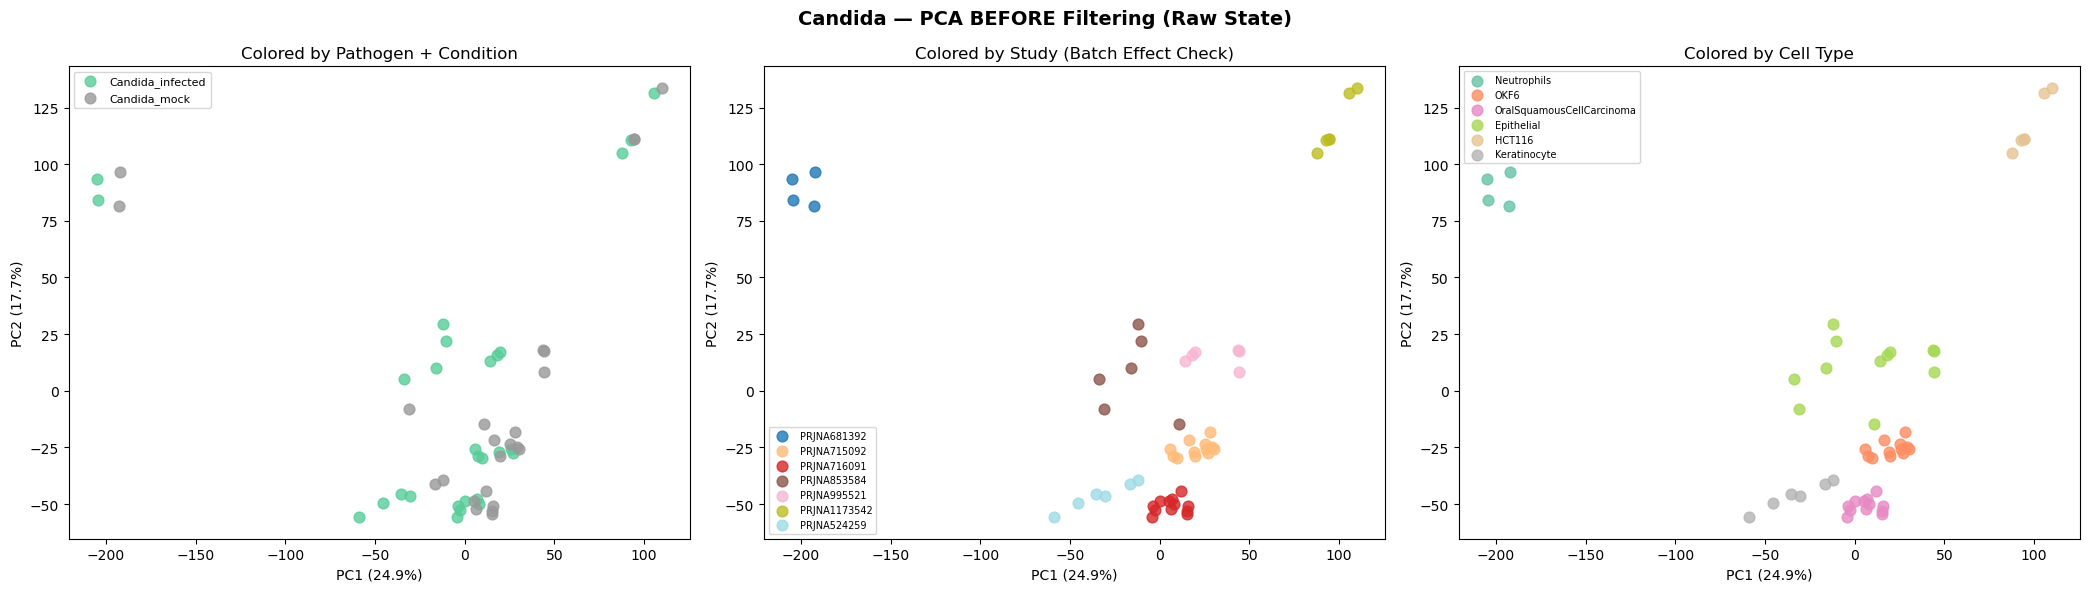

Candida: PC1 24.9%, PC2 17.7% | 52 samples x 18506 genes -> PCA_before_filtering_Candida.png


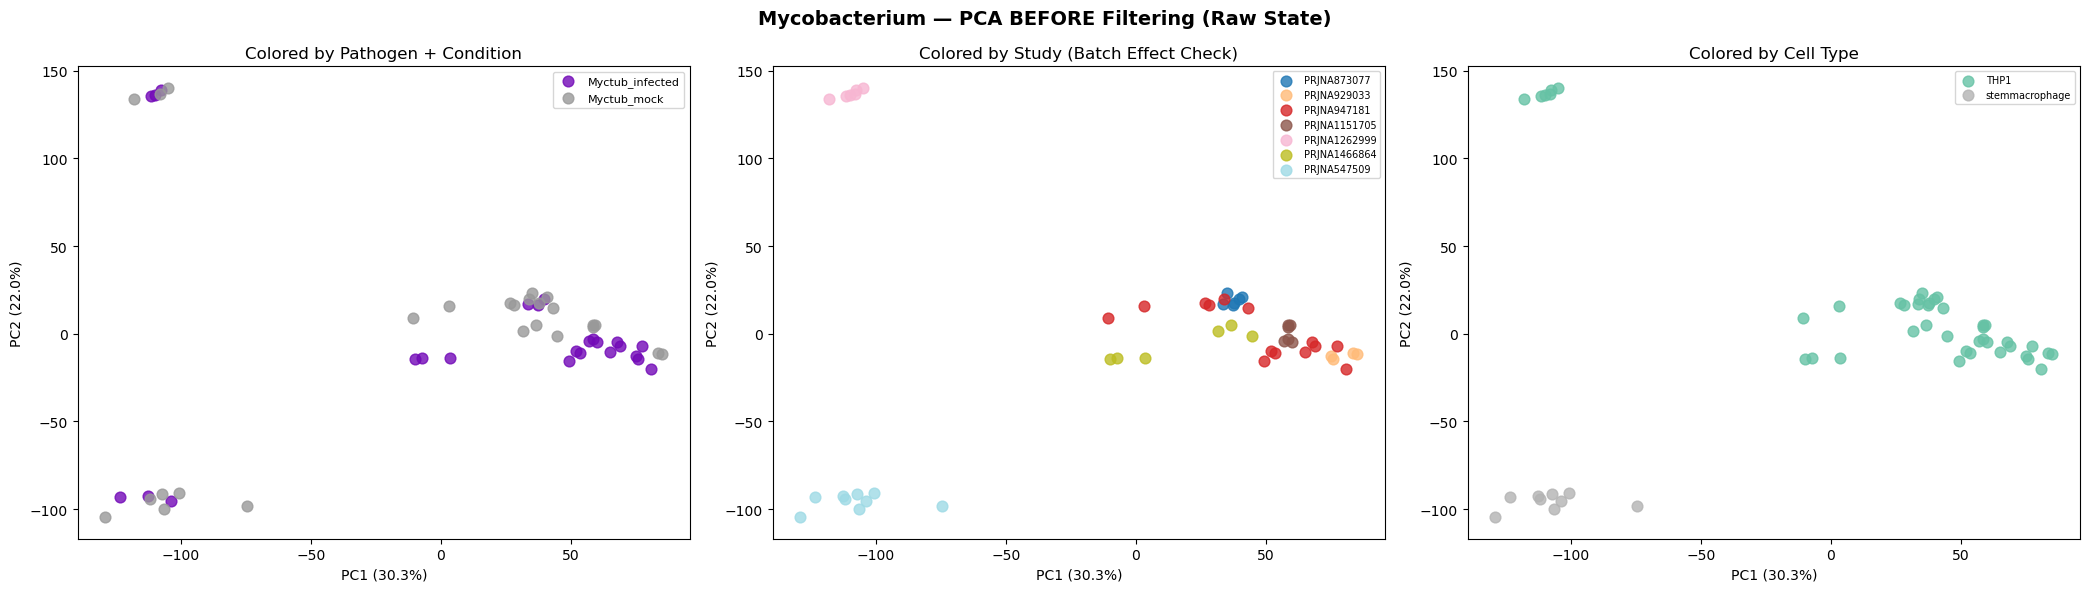

Mycobacterium: PC1 30.3%, PC2 22.0% | 51 samples x 17941 genes -> PCA_before_filtering_Mycobacterium.png


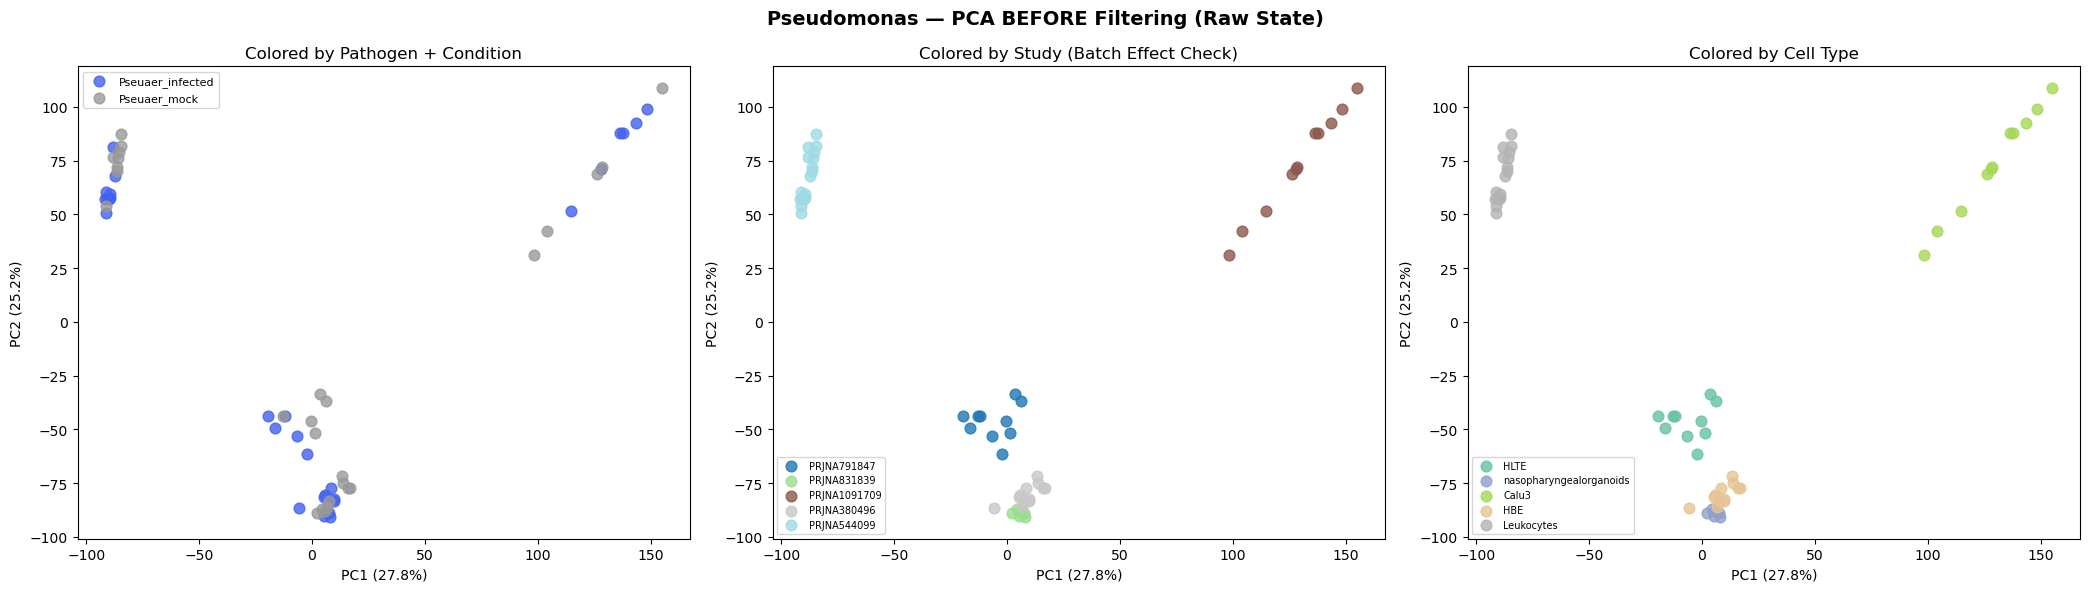

Pseudomonas: PC1 27.8%, PC2 25.2% | 56 samples x 20702 genes -> PCA_before_filtering_Pseudomonas.png


In [56]:
# ============================================================
# STEP 4 - PCA BEFORE ANY CORRECTION (all pathogens)
# ============================================================

PATHOGEN_COLORS = {
    'HSV1': '#E8735A', 'HCMV': '#F4A261', 'Aspergillus': '#2A9D8F',
    'Candida': '#57CC99', 'Pseudomonas': '#4361EE', 'Mycobacterium': '#7209B7',
}
MOCK_COLOR = '#999999'
OUTDIR = Path(r'C:\Users\mariaplumber\Downloads')

pca_by_pathogen = {}

for group in tpm_filt_by_pathogen:
    tpm_filtered = tpm_filt_by_pathogen[group]
    meta         = meta_by_pathogen[group]

    X_log    = np.log2(tpm_filtered + 1).T          # samples x genes
    X_scaled = StandardScaler().fit_transform(X_log)

    n_comp = min(50, X_scaled.shape[0], X_scaled.shape[1])
    pca    = PCA(n_components=n_comp)
    X_pca  = pca.fit_transform(X_scaled)

    n_keep = min(10, n_comp)
    pca_df = pd.DataFrame(X_pca[:, :n_keep], index=meta.index,
                          columns=[f'PC{i+1}' for i in range(n_keep)])
    pca_df = pca_df.join(meta[['pathogen', 'condition', 'study', 'cell_type']])
    pca_df['label'] = pca_df['pathogen'] + '_' + pca_df['condition']

    var_explained = pca.explained_variance_ratio_ * 100
    pca_by_pathogen[group] = {'pca_df': pca_df, 'var_explained': var_explained}

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    fig.suptitle(f'{group} — PCA BEFORE Filtering (Raw State)',
                 fontsize=14, fontweight='bold')

    # plot 1 - colored by pathogen+condition
    for label, grp in pca_df.groupby('label'):
        c = MOCK_COLOR if label.endswith('_mock') else PATHOGEN_COLORS.get(group, 'gray')
        axes[0].scatter(grp['PC1'], grp['PC2'], c=c, label=label, alpha=0.8, s=60)
    axes[0].set_title('Colored by Pathogen + Condition')
    axes[0].legend(fontsize=8)

    # plot 2 - colored by study (batch effect check)
    studies = pca_df['study'].unique()
    colors2 = plt.cm.tab20(np.linspace(0, 1, max(len(studies), 2)))
    for i, study in enumerate(studies):
        grp = pca_df[pca_df['study'] == study]
        axes[1].scatter(grp['PC1'], grp['PC2'], c=[colors2[i]],
                        label=study, alpha=0.8, s=60)
    axes[1].set_title('Colored by Study (Batch Effect Check)')
    axes[1].legend(fontsize=7)

    # plot 3 - colored by cell type
    cell_types = pca_df['cell_type'].unique()
    colors3 = plt.cm.Set2(np.linspace(0, 1, max(len(cell_types), 2)))
    for i, ct in enumerate(cell_types):
        grp = pca_df[pca_df['cell_type'] == ct]
        axes[2].scatter(grp['PC1'], grp['PC2'], c=[colors3[i]],
                        label=ct, alpha=0.8, s=60)
    axes[2].set_title('Colored by Cell Type')
    axes[2].legend(fontsize=7)

    for ax in axes:
        ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}%)')
        ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}%)')

    plt.tight_layout()
    outpath = OUTDIR / f'PCA_before_filtering_{group}.png'
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"{group}: PC1 {var_explained[0]:.1f}%, PC2 {var_explained[1]:.1f}% "
          f"| {X_scaled.shape[0]} samples x {X_scaled.shape[1]} genes -> {outpath.name}")

In [57]:
# ============================================================
# PER-STUDY DESeq2 (all pathogens)
# ============================================================

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

study_results = {}

for group in counts_filt_by_pathogen:
    counts_filtered = counts_filt_by_pathogen[group]
    meta            = meta_by_pathogen[group]

    print(f"\n{'='*60}")
    print(f"Running per-study DESeq2 for {group}...")
    print('='*60)

    for study in meta['study'].unique():
        study_meta   = meta[meta['study'] == study].copy()
        study_counts = counts_filtered[study_meta.index].copy()
        study_counts_int = study_counts.round().astype(int)
        keep = study_counts_int.sum(axis=1) > 0
        study_counts_int = study_counts_int[keep]

        print(f"\n  Study: {study} | "
              f"infected={(study_meta['condition']=='infected').sum()} | "
              f"mock={(study_meta['condition']=='mock').sum()} | "
              f"cell_type={study_meta['cell_type'].unique()}")

        try:
            dds = DeseqDataSet(
                counts=study_counts_int.T,
                metadata=study_meta[['condition']],
                design_factors='condition',
                ref_level=['condition', 'mock']
            )
            dds.deseq2()
            stat_res = DeseqStats(
                dds, contrast=['condition', 'infected', 'mock'])
            stat_res.summary()
            res = stat_res.results_df.copy()
            res = res.dropna(subset=['log2FoldChange', 'padj'])
            study_results[(group, study)] = res
            print(f"  ✓ Done — {len(res)} genes tested")
        except Exception as e:
            print(f"  ✗ Failed: {e}")

print(f"\nCompleted DESeq2 for {len(study_results)} studies")


Running per-study DESeq2 for HSV1...

  Study: PRJNA256013 | infected=2 | mock=2 | cell_type=['HFF1']
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.85 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 0.81 seconds.

Fitting LFCs...
... done in 0.81 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.87 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value: condition infected vs mock
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                 
A1BG            84.713661        0.578419  0.440255  1.313829  0.188904   
A1CF            20.958926        3.651256  0.977879  3.733854  0.000189   
A2M             56.712336       -0.855041  0.625722 -1.366487  0.171786   
A2ML1           13.089148        2.014321  1.068775  1.884700  0.059470   
A2MP1            0.655365        3.240130  5.160537  0.627867  0.530091   
...                   ...             ...       ...       ...       ...   
ZYX            153.600690       -0.857813  0.353672 -2.425449  0.015289   
ZZEF1          650.762726        0.104576  0.227983  0.458703  0.646447   
ZZZ3          1043.212732       -0.424878  0.214751 -1.978470  0.047876   
bP-21264C1.1     4.167358        4.423116  2.350390  1.881864  0.059854   
bP-2189O9.2      9.479794        1.

Fitting dispersions...
... done in 0.77 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 0.80 seconds.

Fitting LFCs...
... done in 0.78 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.79 seconds.

Fitting size factors...
... done in 0.02 seconds.



Log2 fold change & Wald test p-value: condition infected vs mock
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                
A1BG          129.001863        1.724624  0.512381  3.365904  0.000763   
A1CF            2.203986        2.706906  1.493212  1.812807  0.069862   
A2M           681.071197       -0.386211  0.459211 -0.841032  0.400330   
A2ML1           5.934145        0.221998  0.698984  0.317602  0.750787   
A2MP1           1.094840        1.517167  2.413085  0.628725  0.529529   
...                  ...             ...       ...       ...       ...   
ZYG11B        178.501141       -0.957307  0.270869 -3.534201  0.000409   
ZYX           683.717091        0.071369  0.118231  0.603642  0.546082   
ZZEF1         291.611138        0.527883  0.144045  3.664707  0.000248   
ZZZ3          107.904360       -0.608738  0.161168 -3.777046  0.000159   
bP-21264C1.1    0.024696        2.404140  3.778

...

Fitting dispersions...
... done in 0.77 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 0.81 seconds.

Fitting LFCs...
... done in 1.78 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.85 seconds.

Fitting size factors...
... done in 0.02 seconds.



Log2 fold change & Wald test p-value: condition infected vs mock
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                
A1BG           13.215071       -0.042032  0.453409 -0.092702  0.926141   
A1CF            2.400530       -0.219421  0.789532 -0.277912  0.781080   
A2M             2.786262       -0.035517  0.874212 -0.040628  0.967593   
A2ML1         178.434688       -0.105354  0.575906 -0.182935  0.854849   
A2MP1           0.686997       -0.970211  1.973281 -0.491674  0.622950   
...                  ...             ...       ...       ...       ...   
ZZZ3          454.237638       -0.027433  0.225135 -0.121852  0.903016   
bP-21264C1.1    2.167055       -1.223112  0.881523 -1.387498  0.165290   
bP-2171C21.5    1.254814       -0.723882  1.233471 -0.586866  0.557294   
bP-2171C21.6    2.581052       -0.792432  0.758072 -1.045326  0.295872   
bP-2189O9.2     2.874421       -0.284034  0.646

Fitting dispersions...
... done in 0.79 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 1.59 seconds.

Fitting LFCs...
... done in 0.85 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 79 outlier genes.

Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.03 seconds.

Fitting LFCs...
... done in 0.03 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition infected vs mock
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                
A1BG           80.400055       -0.210699  0.157616 -1.336784  0.181293   
A1CF            3.734272       -1.085391  0.590980 -1.836594  0.066270   
A2M           201.425009       -3.516909  0.806749 -4.359359  0.000013   
A2ML1           7.912517        0.178208  0.416439  0.427934  0.668699   
A2MP1          22.352712       -0.957693  0.464581 -2.061415  0.039264   
...                  ...             ...       ...       ...       ...   
ZZZ3          563.578942        0.053068  0.095023  0.558469  0.576524   
bP-21264C1.1    0.923847       -2.958663  1.506851 -1.963474  0.049591   
bP-2171C21.5    0.143953       -0.651161  3.248342 -0.200460  0.841121   
bP-2171C21.6    2.891519        0.126921  0.629579  0.201597  0.840232   
bP-2189O9.2     3.688857        0.144519  0.924

... done in 0.85 seconds.



In [58]:
# ============================================================
# ROBUST GENE SELECTION (all pathogens)
# ============================================================

def get_robust_genes(studies_list, study_results, pathogen, min_studies=2):
    sig_genes = {}
    for study in studies_list:
        if (pathogen, study) not in study_results:
            continue
        res = study_results[(pathogen, study)]
        sig = res[(res['padj'] < 0.05) & (abs(res['log2FoldChange']) > 1)]
        for gene, row in sig.iterrows():
            if gene not in sig_genes:
                sig_genes[gene] = []
            sig_genes[gene].append(np.sign(row['log2FoldChange']))
    robust = {}
    for gene, directions in sig_genes.items():
        if len(directions) >= min_studies:
            if len(set(directions)) == 1:
                robust[gene] = {
                    'n_studies': len(directions),
                    'direction': 'up' if directions[0] > 0 else 'down'
                }
    return robust


# set per pathogen after looking at the sweep below
MIN_STUDIES = {
    'HSV1':          2,
    'HCMV':          2,
    'Aspergillus':   2,
    'Candida':       2,
    'Pseudomonas':   2,
    'Mycobacterium': 2,
}

robust_by_pathogen = {}

for group in meta_by_pathogen:
    studies   = meta_by_pathogen[group]['study'].unique()
    n_studies = sum(1 for (g, s) in study_results if g == group)

    print(f"\n{'='*60}")
    print(f"Gene counts at different thresholds for {group} ({n_studies} studies)")
    print('='*60)

    for min_s in range(2, n_studies + 1):
        robust = get_robust_genes(studies, study_results, group, min_studies=min_s)
        up   = sum(1 for g, v in robust.items() if v['direction'] == 'up')
        down = sum(1 for g, v in robust.items() if v['direction'] == 'down')
        print(f"min_studies={min_s}: {len(robust):5d} genes (up={up}, down={down})")

    chosen = MIN_STUDIES[group]
    robust_by_pathogen[group] = get_robust_genes(studies, study_results, group,
                                                 min_studies=chosen)
    print(f"  -> using min_studies={chosen}: "
          f"{len(robust_by_pathogen[group])} genes")

    study_dist = pd.Series({g: v['n_studies']
                            for g, v in robust_by_pathogen[group].items()}
                           ).value_counts().sort_index()
    print("\n  Distribution of genes by number of studies:")
    print(study_dist.to_string() if len(study_dist) else "  (none)")

print(f"\n{'='*60}\nFINAL COUNTS\n{'='*60}")
for g, r in robust_by_pathogen.items():
    up = sum(1 for v in r.values() if v['direction'] == 'up')
    print(f"  {g:14s} min_studies={MIN_STUDIES[g]:2d}  {len(r):5d} genes "
          f"(up={up}, down={len(r)-up})")


Gene counts at different thresholds for HSV1 (6 studies)
min_studies=2:  6157 genes (up=4150, down=2007)
min_studies=3:  2892 genes (up=2145, down=747)
min_studies=4:  1336 genes (up=1075, down=261)
min_studies=5:   530 genes (up=466, down=64)
min_studies=6:   151 genes (up=144, down=7)
  -> using min_studies=2: 6157 genes

  Distribution of genes by number of studies:
2    3265
3    1556
4     806
5     379
6     151

Gene counts at different thresholds for HCMV (7 studies)
min_studies=2:  4717 genes (up=2582, down=2135)
min_studies=3:  2840 genes (up=1565, down=1275)
min_studies=4:  1418 genes (up=837, down=581)
min_studies=5:   793 genes (up=473, down=320)
min_studies=6:   292 genes (up=208, down=84)
min_studies=7:    38 genes (up=38, down=0)
  -> using min_studies=2: 4717 genes

  Distribution of genes by number of studies:
2    1877
3    1422
4     625
5     501
6     254
7      38

Gene counts at different thresholds for Aspergillus (6 studies)
min_studies=2:   721 genes (up=624

Total genes with complete 6-pathogen LFC: 35300
  HSV1            6157 genes at min_studies=2
  HCMV            4717 genes at min_studies=2
  Aspergillus      721 genes at min_studies=2
  Candida          518 genes at min_studies=2
  Mycobacterium   2276 genes at min_studies=2
  Pseudomonas      314 genes at min_studies=2

Category counts:
category
Unfiltered       24569
HSV1              3977
Shared            3102
HCMV              2498
Mycobacterium      830
Aspergillus        135
Candida            118
Pseudomonas         71
Name: count, dtype: int64


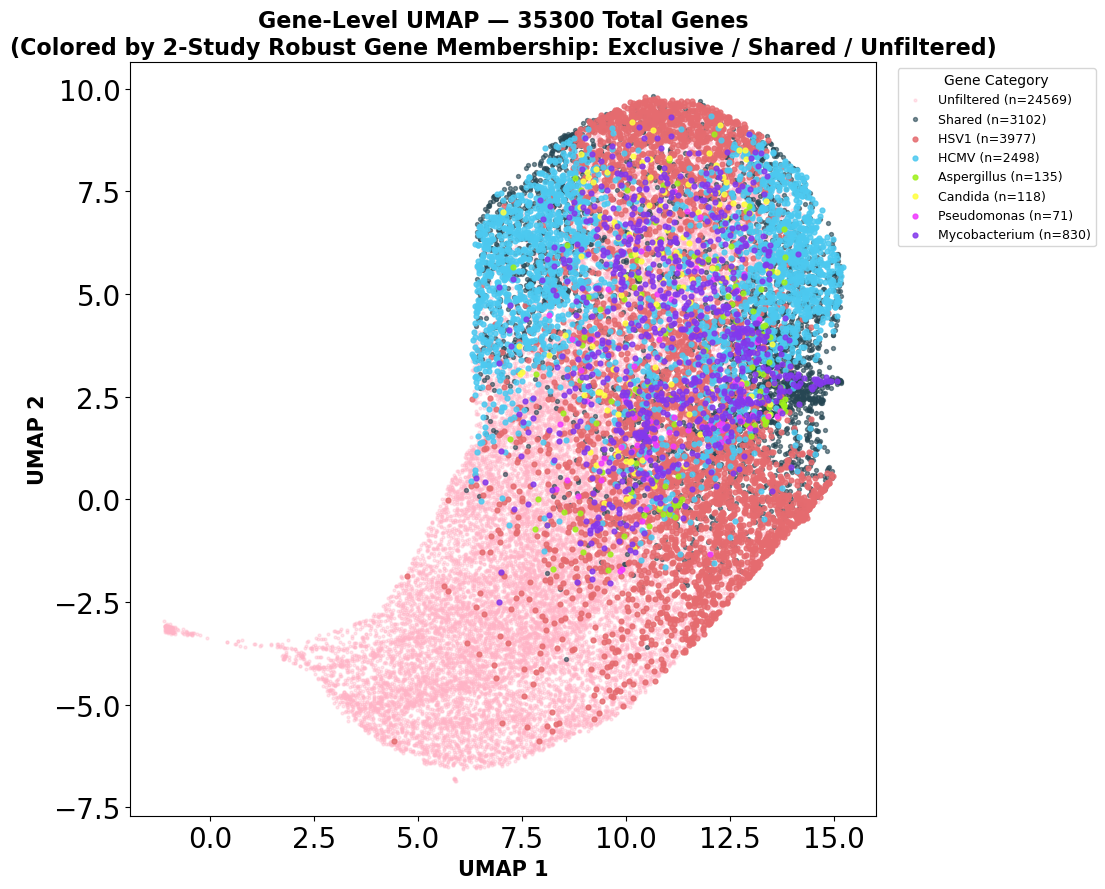

Saved.


In [59]:
import umap

PATHOGEN_COLORS = {
    'HSV1': '#e56b6f', 'HCMV': '#4cc9f0', 'Aspergillus': '#9ef01a',
    'Candida': '#ffff3f', 'Pseudomonas': '#f038ff', 'Mycobacterium': '#8338ec',
}
PATHS = list(PATHOGEN_COLORS.keys())

# ---- pool the per-pathogen matrices (gene space is identical across all six) ----
tpm_gene_pooled = pd.concat(
    [tpm_gene_by_pathogen[g] for g in tpm_gene_by_pathogen], axis=1
)
meta_pooled = pd.concat(
    [meta_by_pathogen[g] for g in meta_by_pathogen]
).loc[tpm_gene_pooled.columns]

# ============================================================
# STEP 1 — build per-gene average LFC per pathogen (6 features), all genes
# ============================================================
gene_lfc = {}
for group in meta_by_pathogen:
    samples = meta_pooled[meta_pooled['group'] == group]
    infected_samples = samples[samples['condition'] == 'infected'].index.tolist()
    mock_samples     = samples[samples['condition'] == 'mock'].index.tolist()
    inf_mean  = np.log2(tpm_gene_pooled[infected_samples] + 1).mean(axis=1)
    mock_mean = np.log2(tpm_gene_pooled[mock_samples] + 1).mean(axis=1)
    gene_lfc[group] = inf_mean - mock_mean
gene_feats = pd.DataFrame(gene_lfc).dropna()
print(f"Total genes with complete 6-pathogen LFC: {len(gene_feats)}")

# ============================================================
# STEP 2 — assign each gene to: exclusive / shared / unfiltered
# using the 2-study robust gene sets
# ============================================================
robust_2study = {
    g: set(get_robust_genes(meta_by_pathogen[g]['study'].unique(),
                            study_results, g, min_studies=2).keys())
    for g in meta_by_pathogen
}
for g, s in robust_2study.items():
    print(f"  {g:14s} {len(s):5d} genes at min_studies=2")

def classify_gene(gene):
    memberships = [p for p in PATHS if gene in robust_2study[p]]
    if len(memberships) == 0:
        return 'Unfiltered'
    elif len(memberships) == 1:
        return memberships[0]
    else:
        return 'Shared'

gene_feats['category'] = [classify_gene(g) for g in gene_feats.index]
print("\nCategory counts:")
print(gene_feats['category'].value_counts())

# ============================================================
# STEP 3 — UMAP embedding (all genes, 6 LFC features)
# ============================================================
X_genes = gene_feats[PATHS].astype(float).values
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
embedding = reducer.fit_transform(X_genes)
gene_feats['UMAP1'] = embedding[:, 0]
gene_feats['UMAP2'] = embedding[:, 1]

# ============================================================
# STEP 4 — plot
# ============================================================
fig, ax = plt.subplots(figsize=(11, 9))

unf = gene_feats[gene_feats['category'] == 'Unfiltered']
ax.scatter(unf['UMAP1'], unf['UMAP2'], s=4, c='#ffb3c6', alpha=0.35,
           label=f'Unfiltered (n={len(unf)})', zorder=1)

shared = gene_feats[gene_feats['category'] == 'Shared']
ax.scatter(shared['UMAP1'], shared['UMAP2'], s=8, c='#264653', alpha=0.6,
           label=f'Shared (n={len(shared)})', zorder=2)

for p in PATHS:
    grp = gene_feats[gene_feats['category'] == p]
    ax.scatter(grp['UMAP1'], grp['UMAP2'], s=12, c=PATHOGEN_COLORS[p], alpha=0.85,
               label=f'{p} (n={len(grp)})', zorder=3)

ax.set_xlabel('UMAP 1', fontsize=15, fontweight='bold')
ax.set_ylabel('UMAP 2', fontsize=15, fontweight='bold')
ax.set_title(f'Gene-Level UMAP — {len(gene_feats)} Total Genes\n'
             f'(Colored by 2-Study Robust Gene Membership: Exclusive / Shared / Unfiltered)',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=9, title='Gene Category', title_fontsize=10,
          bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.savefig(r'C:\Users\mariaplumber\Downloads\gene_UMAP_exclusive_shared_unfiltered.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")

In [60]:
# ============================================================
# SAVE ROBUST GENES (all pathogens)
# ============================================================

MIN_STUDIES = {
    'HSV1':          6,
    'HCMV':          6,
    'Aspergillus':   5,
    'Candida':       4,
    'Mycobacterium': 6,
    'Pseudomonas':   3,
}

OUT_NAMES = {
    'HSV1':          'HHV1_robust_genes.csv',
    'HCMV':          'HCMV_robust_genes.csv',
    'Aspergillus':   'Aspergillus_robust_genes.csv',
    'Candida':       'Candida_robust_genes.csv',
    'Mycobacterium': 'Myc_robust_genes.csv',
    'Pseudomonas':   'Pseu_robust_genes.csv',
}

OUTDIR = Path(r'C:\Users\mariaplumber\Downloads')

final_robust  = {}
gene_df_by_pathogen = {}

for group in meta_by_pathogen:
    studies   = meta_by_pathogen[group]['study'].unique()
    n_studies = sum(1 for (g, s) in study_results if g == group)
    min_s     = MIN_STUDIES[group]

    if min_s > n_studies:
        print(f"[WARN] {group}: min_studies={min_s} but only {n_studies} "
              f"studies have results -> 0 genes")

    final_strict = get_robust_genes(studies, study_results, group,
                                    min_studies=min_s)
    final_robust[group] = final_strict

    gene_df = pd.DataFrame([
        {'gene': g, 'direction': v['direction'], 'n_studies': v['n_studies']}
        for g, v in final_strict.items()
    ])
    if len(gene_df):
        gene_df = gene_df.sort_values(['direction', 'gene']).reset_index(drop=True)
    gene_df_by_pathogen[group] = gene_df

    outpath = OUTDIR / OUT_NAMES[group]
    gene_df.to_csv(outpath, index=False)

    up = int((gene_df['direction'] == 'up').sum()) if len(gene_df) else 0
    print(f"{group:14s} min_studies={min_s}/{n_studies}  "
          f"{len(gene_df):5d} genes (up={up}, down={len(gene_df)-up})  "
          f"-> {OUT_NAMES[group]}")

total = sum(len(df) for df in gene_df_by_pathogen.values())
print(f"\nTotal gene-pathogen entries saved: {total}")

HSV1           min_studies=6/6    151 genes (up=144, down=7)  -> HHV1_robust_genes.csv
HCMV           min_studies=6/7    292 genes (up=208, down=84)  -> HCMV_robust_genes.csv
Aspergillus    min_studies=5/6     77 genes (up=76, down=1)  -> Aspergillus_robust_genes.csv
Candida        min_studies=4/7     47 genes (up=47, down=0)  -> Candida_robust_genes.csv
Mycobacterium  min_studies=6/7     44 genes (up=44, down=0)  -> Myc_robust_genes.csv
Pseudomonas    min_studies=3/5     40 genes (up=38, down=2)  -> Pseu_robust_genes.csv

Total gene-pathogen entries saved: 651


Total robust gene entries: 651
Unique genes: 605
pathogen
Aspergillus       77
Candida           47
HCMV             292
HSV1             151
Mycobacterium     44
Pseudomonas       40
dtype: int64
Row order for PowerPoint labels (bottom row first):
  row 0 (from bottom): HCMV  [292 genes]
  row 1 (from bottom): HSV1  [151 genes]
  row 2 (from bottom): Aspergillus  [77 genes]
  row 3 (from bottom): Candida  [47 genes]
  row 4 (from bottom): Mycobacterium  [44 genes]
  row 5 (from bottom): Pseudomonas  [40 genes]

Showing 24 of 24 intersections; genes represented: 605 / 605


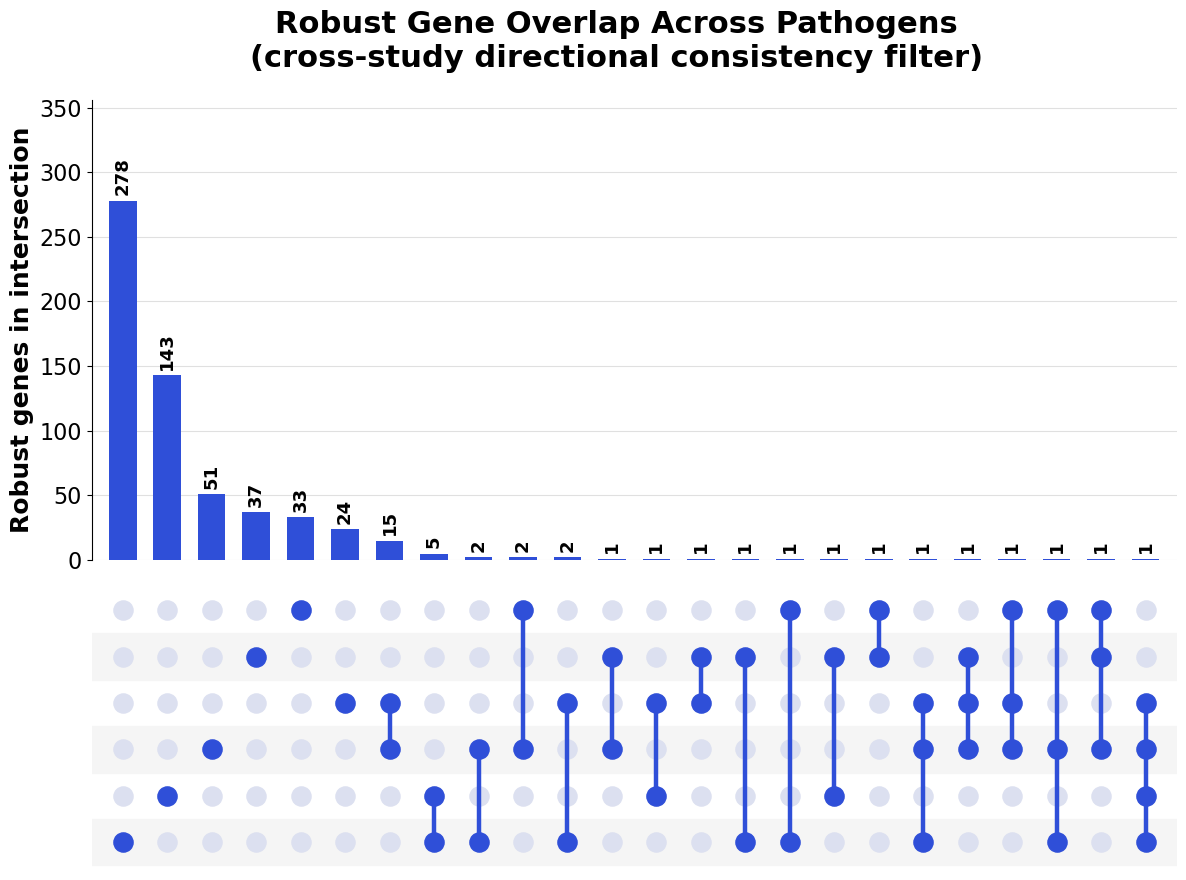

In [62]:
# ============================================================
# STEP 4c — UPSET PLOT OF ROBUST GENE SETS (large fonts, 300 dpi)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import Counter
robust_long = pd.concat(
    [df.assign(pathogen=g) for g, df in gene_df_by_pathogen.items()],
    ignore_index=True
)[['pathogen', 'gene', 'direction']]

print(f"Total robust gene entries: {len(robust_long)}")
print(f"Unique genes: {robust_long['gene'].nunique()}")
print(robust_long.groupby('pathogen').size())
PATHOGEN_COLORS = {
    'HSV1':          '#E8735A',
    'HCMV':          '#F4A261',
    'Aspergillus':   '#2A9D8F',
    'Candida':       '#57CC99',
    'Pseudomonas':   '#4361EE',
    'Mycobacterium': '#7209B7',
}
BAR_COLOR = '#2F4FD8'
DOT_OFF   = '#DCE0F0'

MAX_INTERSECTIONS = 45
MIN_SIZE          = 1

# ---- font sizes (tweak here) ----
FS_TITLE     = 22
FS_AXLABEL   = 18
FS_TICK      = 16
FS_BARLABEL  = 13
DOT_SIZE     = 190
LINE_W       = 3.2
DPI          = 300

# ---- 1. membership per gene ----
gene_membership = robust_long.groupby('gene')['pathogen'].apply(lambda s: frozenset(s))
inter_counts = Counter(gene_membership.values)

# ---- 2. row order (largest set at the bottom) ----
set_sizes = robust_long.groupby('pathogen')['gene'].nunique().sort_values(ascending=False)
path_order = list(set_sizes.index)
y_pos = {p: i for i, p in enumerate(path_order)}

print("Row order for PowerPoint labels (bottom row first):")
for i, p in enumerate(path_order):
    print(f"  row {i} (from bottom): {p}  [{set_sizes[p]} genes]")

# ---- 3. order intersections: size desc, then degree asc ----
intersections = [(combo, n) for combo, n in inter_counts.items() if n >= MIN_SIZE]
intersections.sort(key=lambda x: (-x[1], len(x[0]), sorted(x[0])))
intersections = intersections[:MAX_INTERSECTIONS]

n_cols = len(intersections)
print(f"\nShowing {n_cols} of {len(inter_counts)} intersections; "
      f"genes represented: {sum(n for _, n in intersections)} / {len(gene_membership)}")

# ---- 4. figure (wider/taller so the bigger text has room) ----
fig = plt.figure(figsize=(max(14, 0.45 * n_cols + 3), 10))
gs = GridSpec(2, 1, height_ratios=[2.4, 1.5], hspace=0.06, figure=fig)

ax_bar    = fig.add_subplot(gs[0])
ax_matrix = fig.add_subplot(gs[1], sharex=ax_bar)

x = np.arange(n_cols)
sizes = [n for _, n in intersections]

# ---- top: intersection sizes ----
ax_bar.bar(x, sizes, color=BAR_COLOR, width=0.62)
for xi, n in zip(x, sizes):
    ax_bar.text(xi, n + max(sizes) * 0.015, str(n), ha='center', va='bottom',
                rotation=90, fontsize=FS_BARLABEL, fontweight='bold')
ax_bar.set_ylabel('Robust genes in intersection', fontsize=FS_AXLABEL, fontweight='bold')
ax_bar.set_ylim(0, max(sizes) * 1.28)
ax_bar.tick_params(axis='y', labelsize=FS_TICK)
ax_bar.grid(axis='y', color='0.88', lw=0.8)
ax_bar.set_axisbelow(True)
for s in ['top', 'right', 'bottom']:
    ax_bar.spines[s].set_visible(False)
ax_bar.tick_params(axis='x', bottom=False, labelbottom=False)

# ---- bottom: dot matrix ----
for i in range(len(path_order)):
    if i % 2 == 0:
        ax_matrix.axhspan(i - 0.5, i + 0.5, color='0.96', zorder=0)

for xi, (combo, _) in enumerate(intersections):
    ys = sorted(y_pos[p] for p in combo)
    ax_matrix.scatter([xi] * len(path_order), range(len(path_order)),
                      s=DOT_SIZE, color=DOT_OFF, zorder=1)
    if len(ys) > 1:
        ax_matrix.plot([xi, xi], [min(ys), max(ys)], color=BAR_COLOR, lw=LINE_W, zorder=2)
    ax_matrix.scatter([xi] * len(ys), ys, s=DOT_SIZE, color=BAR_COLOR, zorder=3)

ax_matrix.set_yticks(range(len(path_order)))
ax_matrix.set_yticklabels([])
ax_matrix.set_ylim(-0.6, len(path_order) - 0.4)
ax_matrix.set_xlim(-0.7, n_cols - 0.3)
ax_matrix.tick_params(axis='x', bottom=False, labelbottom=False)
ax_matrix.tick_params(axis='y', left=False, labelleft=False)
for s in ax_matrix.spines.values():
    s.set_visible(False)

fig.suptitle('Robust Gene Overlap Across Pathogens\n'
             '(cross-study directional consistency filter)',
             fontsize=FS_TITLE, fontweight='bold', y=0.97)

plt.savefig(r'C:\Users\mariaplumber\Downloads\figures\upset_robust_genes.png',
            dpi=DPI, bbox_inches='tight', pad_inches=0.4, facecolor='white')
plt.show()

               exclusive  shared  total
pathogen                               
HSV1                 143       8    151
HCMV                 278      14    292
Aspergillus           51      26     77
Candida               24      23     47
Pseudomonas           33       7     40
Mycobacterium         37       7     44


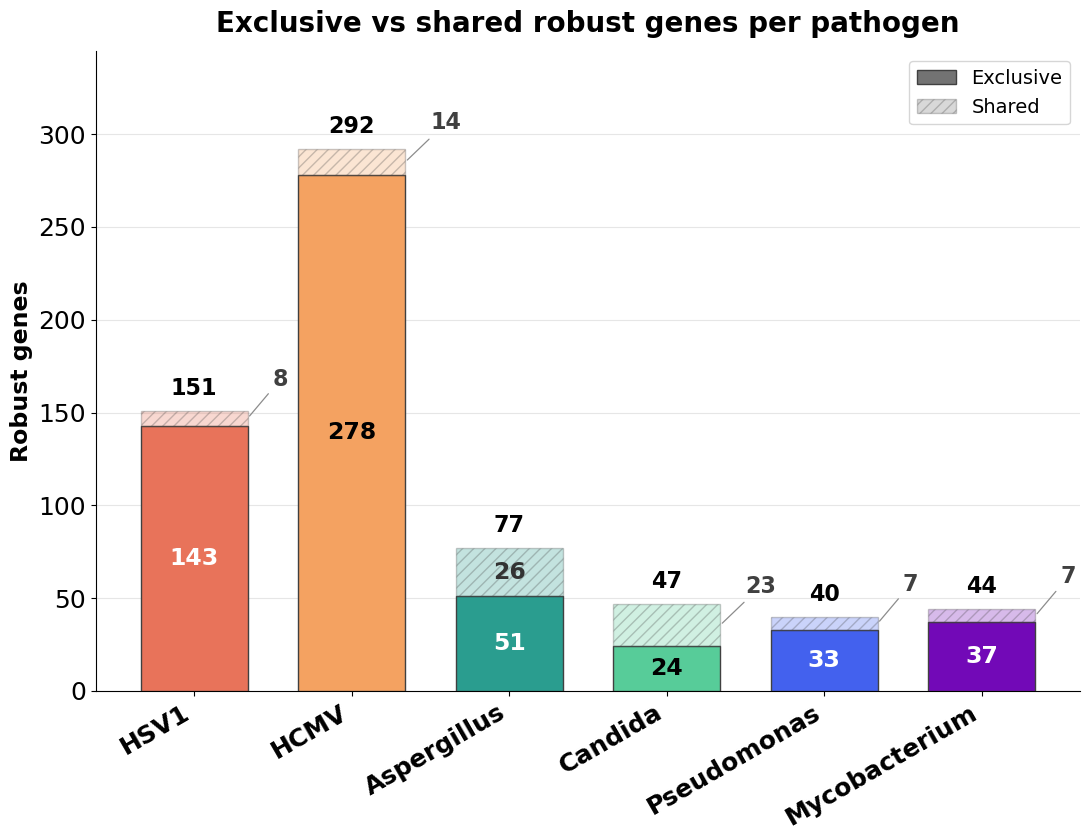

In [63]:
# ============================================================
# STEP 4d — EXCLUSIVE VS SHARED (large fonts, 300 dpi)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

FS_TITLE    = 20
FS_AXLABEL  = 17
FS_TICK      = 18
FS_SEGLABEL = 17
FS_TOTAL    = 16
FS_LEGEND   = 14
DPI         = 300
SORT_BY_TOTAL = False

def contrast_text_color(hex_color):
    """Return black or white depending on which is more readable on this background."""
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return 'black' if luminance > 0.6 else 'white'

n_path_per_gene = robust_long.groupby('gene')['pathogen'].nunique()
robust_long['is_shared'] = robust_long['gene'].map(n_path_per_gene) > 1
summary = (
    robust_long
    .groupby('pathogen')['is_shared']
    .agg(exclusive=lambda s: int((~s).sum()),
         shared=lambda s: int(s.sum()))
)
summary['total'] = summary['exclusive'] + summary['shared']
order = (summary.sort_values('total', ascending=False).index.tolist()
         if SORT_BY_TOTAL else
         [p for p in PATHOGEN_COLORS.keys() if p in summary.index])
summary = summary.loc[order]
print(summary.to_string())

x = np.arange(len(order))
excl = summary['exclusive'].values
shar = summary['shared'].values
tot  = summary['total'].values
colors = [PATHOGEN_COLORS[p] for p in order]

fig, ax = plt.subplots(figsize=(11, 8.5))
ax.bar(x, excl, width=0.68, color=colors, edgecolor='0.25', lw=1.0, zorder=3)
ax.bar(x, shar, width=0.68, bottom=excl, color=colors, alpha=0.28,
       edgecolor='0.25', lw=1.0, hatch='///', zorder=3)

ymax = tot.max()

def seg_label(xi, bottom, height, text, base_color):
    if height <= 0:
        return
    if height >= ymax * 0.08:
        ax.text(xi, bottom + height / 2, str(text), ha='center', va='center',
                fontsize=FS_SEGLABEL, fontweight='bold', color=base_color, zorder=5)
    else:
        ax.annotate(str(text),
                    xy=(xi + 0.34, bottom + height / 2),
                    xytext=(xi + 0.50, bottom + height / 2 + ymax * 0.06),
                    fontsize=FS_SEGLABEL - 1, fontweight='bold', color='0.25', zorder=5,
                    arrowprops=dict(arrowstyle='-', lw=0.9, color='0.55'))

for xi, e, s, t, col in zip(x, excl, shar, tot, colors):
    label_color = contrast_text_color(col)
    seg_label(xi, 0, e, e, label_color)
    seg_label(xi, e, s, s, '0.2')
    ax.text(xi, t + ymax * 0.02, str(t), ha='center', va='bottom',
            fontsize=FS_TOTAL, fontweight='bold', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha='right', fontsize=FS_TICK, fontweight='bold')
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.set_ylabel('Robust genes', fontsize=FS_AXLABEL, fontweight='bold')
ax.set_ylim(0, ymax * 1.18)
ax.grid(axis='y', color='0.9', lw=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.legend(handles=[
    Patch(facecolor='0.45', edgecolor='0.25', label='Exclusive'),
    Patch(facecolor='0.45', edgecolor='0.25', alpha=0.28, hatch='///', label='Shared'),
], loc='upper right', frameon=True, fontsize=FS_LEGEND)
ax.set_title('Exclusive vs shared robust genes per pathogen',
             fontsize=FS_TITLE, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(r'C:\Users\mariaplumber\Downloads\figures\exclusive_vs_shared_robust.png',
            dpi=DPI, bbox_inches='tight', pad_inches=0.3, facecolor='white')
plt.show()


=== HSV1 (min_studies=6) ===
Final signature: 151 genes  (up=144, down=7)


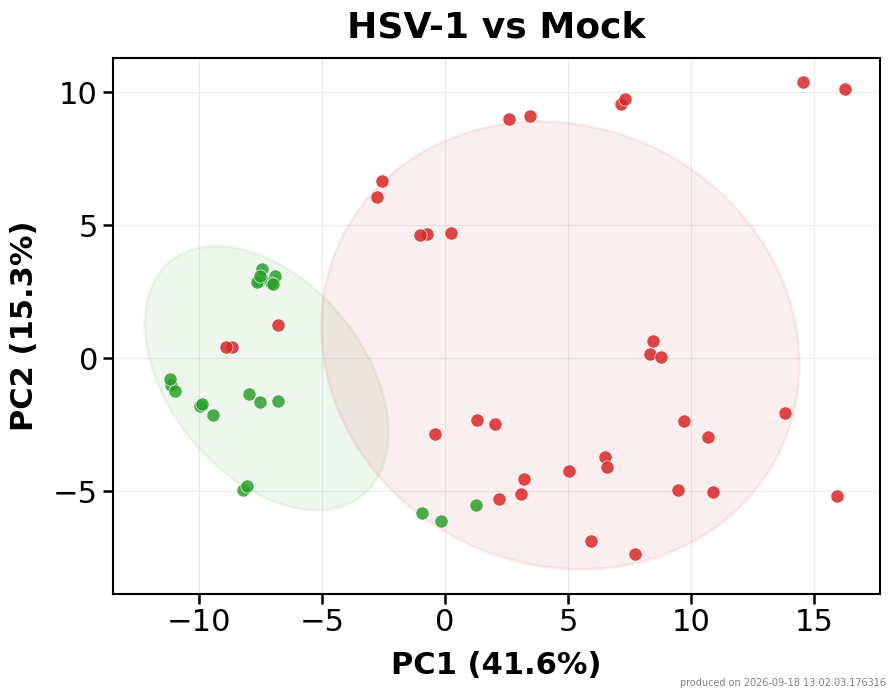

  PC1 41.6%, PC2 15.3%  | 56 samples x 151 genes -> HSV1_PCA_final_genes.png

=== HCMV (min_studies=6) ===
Final signature: 292 genes  (up=208, down=84)


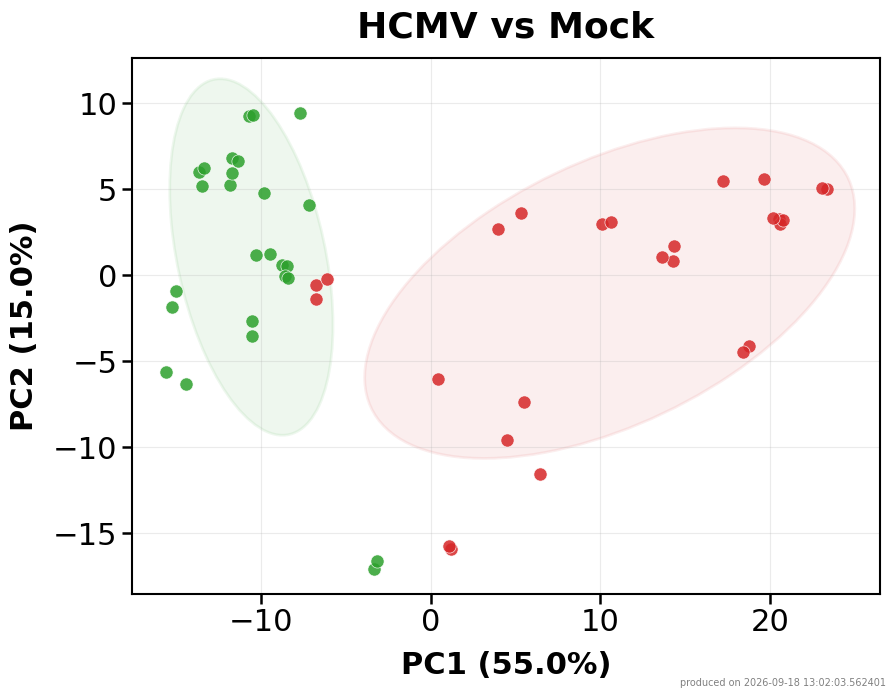

  PC1 55.0%, PC2 15.0%  | 52 samples x 292 genes -> HCMV_PCA_final_genes.png

=== Aspergillus (min_studies=5) ===
Final signature: 77 genes  (up=76, down=1)


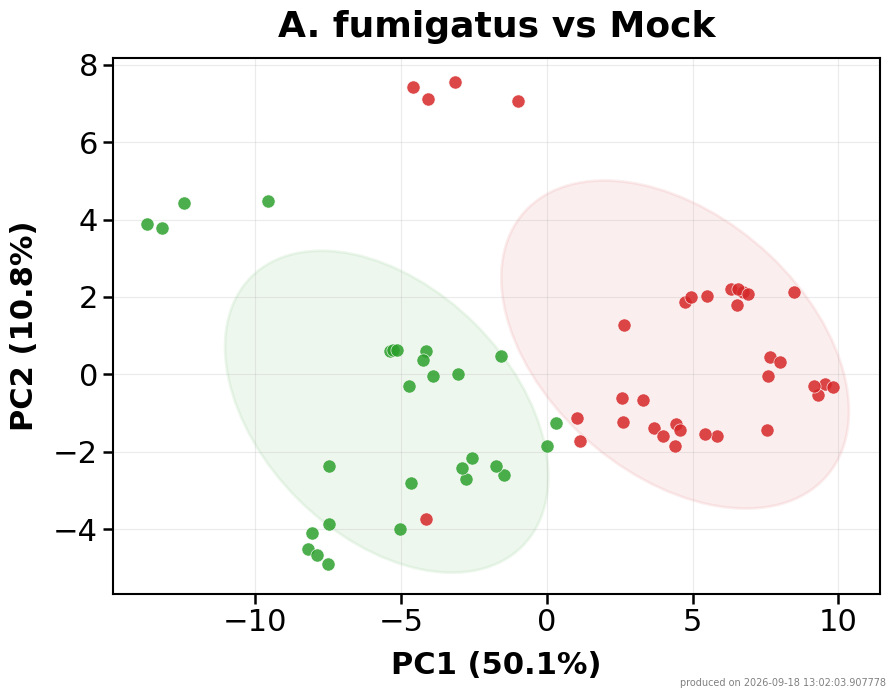

  PC1 50.1%, PC2 10.8%  | 63 samples x 77 genes -> Aspergillus_PCA_final_genes.png

=== Candida (min_studies=4) ===
Final signature: 47 genes  (up=47, down=0)


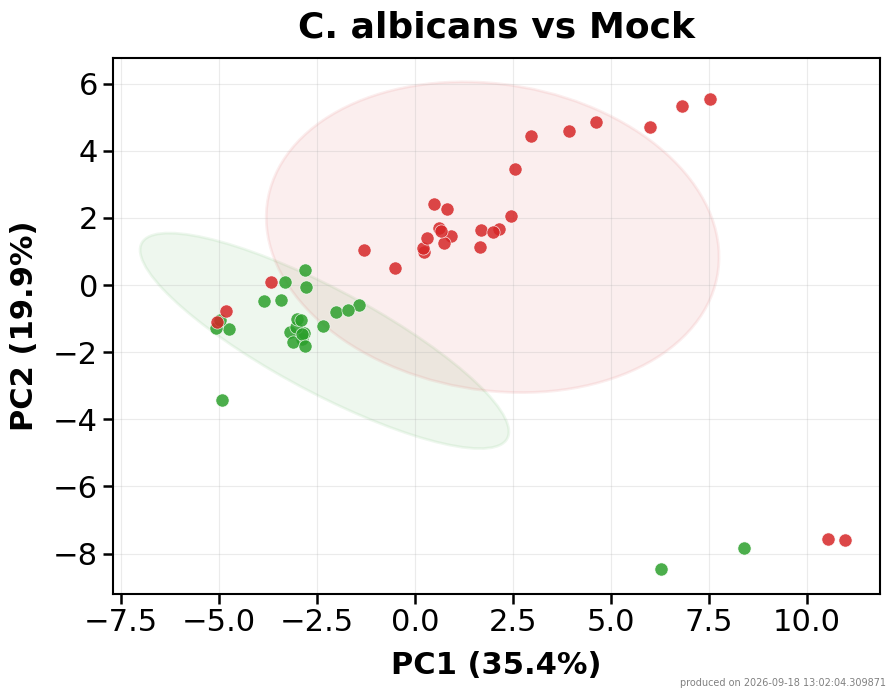

  PC1 35.4%, PC2 19.9%  | 52 samples x 47 genes -> Candida_PCA_final_genes.png

=== Mycobacterium (min_studies=6) ===
Final signature: 44 genes  (up=44, down=0)


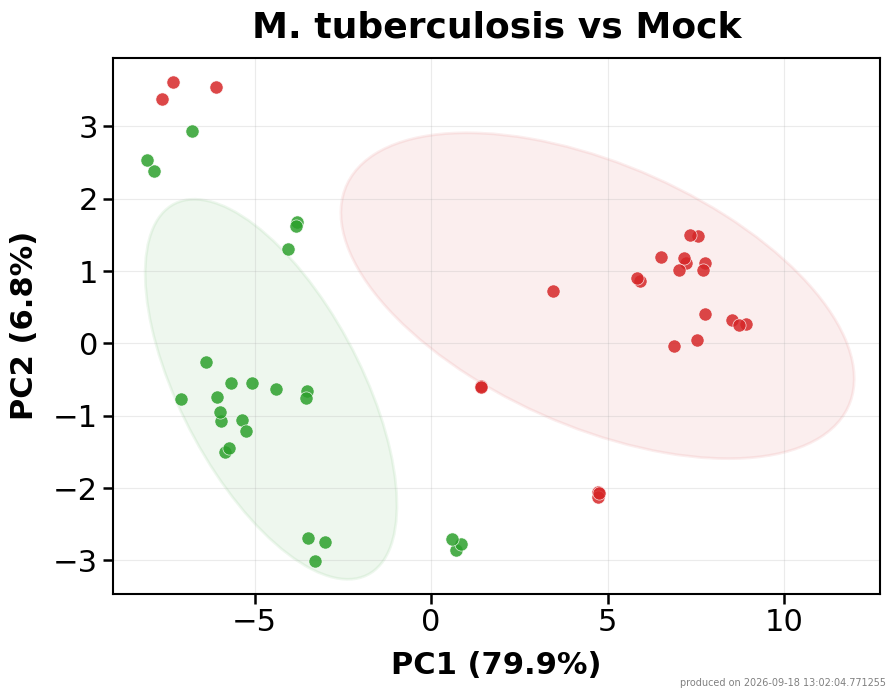

  PC1 79.9%, PC2 6.8%  | 51 samples x 44 genes -> Myc_PCA_final_genes.png

=== Pseudomonas (min_studies=3) ===
Final signature: 40 genes  (up=38, down=2)


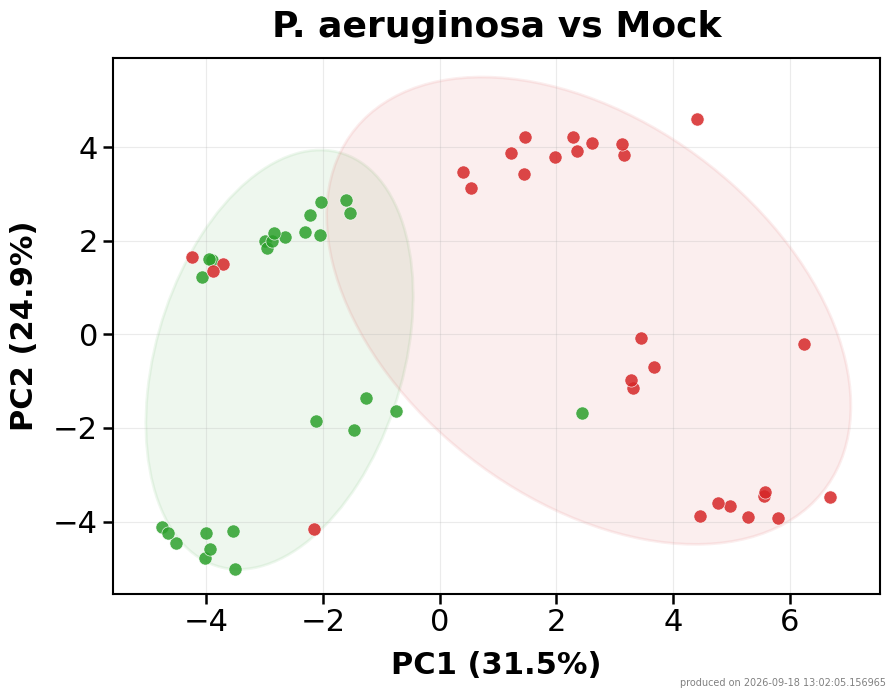

  PC1 31.5%, PC2 24.9%  | 56 samples x 40 genes -> Pseu_PCA_final_genes.png


In [64]:
# ============================================================
# FINAL PCA ON ROBUST GENES (all pathogens)
# ============================================================

import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
from datetime import datetime


def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)


INFECTED_COLOR = '#D62728'   
MOCK_COLOR = '#2CA02C'

PLOT_LABELS = {
    'HSV1': 'HSV-1', 'HCMV': 'HCMV', 'Aspergillus': 'A. fumigatus',
    'Candida': 'C. albicans', 'Pseudomonas': 'P. aeruginosa',
    'Mycobacterium': 'M. tuberculosis',
}

FIG_NAMES = {
    'HSV1':          'HSV1_PCA_final_genes.png',
    'HCMV':          'HCMV_PCA_final_genes.png',
    'Aspergillus':   'Aspergillus_PCA_final_genes.png',
    'Candida':       'Candida_PCA_final_genes.png',
    'Mycobacterium': 'Myc_PCA_final_genes.png',
    'Pseudomonas':   'Pseu_PCA_final_genes.png',
}

OUTDIR = Path(r'C:\Users\mariaplumber\Downloads')
pca_final_by_pathogen = {}

for group in meta_by_pathogen:
    final_genes  = final_robust[group]
    meta         = meta_by_pathogen[group]
    tpm_filtered = tpm_filt_by_pathogen[group]

    up   = sum(1 for v in final_genes.values() if v['direction'] == 'up')
    down = len(final_genes) - up
    print(f"\n=== {group} (min_studies={MIN_STUDIES[group]}) ===")
    print(f"Final signature: {len(final_genes)} genes  (up={up}, down={down})")

    if len(final_genes) < 3:
        print("  [SKIP] too few genes to run PCA")
        continue

    tpm_strict = tpm_filtered.loc[
        tpm_filtered.index.isin(final_genes.keys()), meta.index
    ]

    X        = np.log2(tpm_strict + 1).T
    X_scaled = StandardScaler().fit_transform(X)
    n_comp   = min(10, X_scaled.shape[0], X_scaled.shape[1])
    pca_obj  = PCA(n_components=n_comp)
    X_pca    = pca_obj.fit_transform(X_scaled)
    var_exp  = pca_obj.explained_variance_ratio_ * 100

    n_keep = min(3, n_comp)
    pca_df = pd.DataFrame(X_pca[:, :n_keep], index=meta.index,
                          columns=[f'PC{i+1}' for i in range(n_keep)])
    pca_df = pca_df.join(meta[['condition', 'study', 'cell_type']])
    pca_final_by_pathogen[group] = {'pca_df': pca_df, 'var': var_exp}

    fig, ax = plt.subplots(figsize=(9, 7))
    colors = {'infected': INFECTED_COLOR, 'mock': MOCK_COLOR}

    for cond in ['mock', 'infected']:
        grp = pca_df[pca_df['condition'] == cond]
        if grp.empty:
            continue
        ax.scatter(
            grp['PC1'], grp['PC2'],
            c=colors[cond], s=90, alpha=0.85,
            label=PLOT_LABELS[group] if cond == 'infected' else 'Mock',
            edgecolors='white', linewidths=0.5, zorder=3
        )
        confidence_ellipse(
            grp['PC1'].values, grp['PC2'].values, ax,
            n_std=1.5, edgecolor=colors[cond], linewidth=2,
            facecolor=colors[cond], alpha=0.08
        )

    ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', fontsize=22,
                  fontweight='bold', labelpad=10)
    ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', fontsize=22,
                  fontweight='bold', labelpad=10)
    ax.set_title(f'{PLOT_LABELS[group]} vs Mock', fontsize=26,
                 fontweight='bold', pad=15)
    ax.tick_params(axis='both', which='major', labelsize=22, width=1.8, length=7)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.grid(True, alpha=0.25)
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')
    fig.text(0.99, 0.01, f'produced on {timestamp}',
             ha='right', va='bottom', fontsize=7, color='gray')

    plt.tight_layout()
    outpath = OUTDIR / FIG_NAMES[group]
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  PC1 {var_exp[0]:.1f}%, PC2 {var_exp[1]:.1f}%  "
          f"| {X_scaled.shape[0]} samples x {X_scaled.shape[1]} genes "
          f"-> {outpath.name}")